###Importing necessary libraries

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Display all columns
pd.set_option('display.max_columns', None)

# SharePlate - Surplus Food Prediction

In this notebook we will:

1. Load the dataset
2. Understand the data
3. Check missing values
4. Check duplicates
5. Analyze features
6. Create new features
7. Save processed data for model training

In [19]:
uploaded = files.upload()

Saving food_surplus_prediction_india.csv to food_surplus_prediction_india.csv


##Load Dataset

In [20]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25


## Basic Information About Dataset

In [21]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1782
Columns : 11


In [22]:
df.columns.tolist()

['Type of Food',
 'Number of Guests',
 'Event Type',
 'Quantity of Food',
 'Storage Conditions',
 'Purchase History',
 'Seasonality',
 'Preparation Method',
 'Geographical Location',
 'Pricing',
 'Wastage Food Amount']

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


### Duplicate Handling

In [24]:
df.duplicated().sum()

np.int64(164)

In [25]:
df[df.duplicated()].head(10)

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
163,Fruits,220,Birthday,300,Room Temperature,Regular,All Seasons,Finger Food,Suburban,Moderate,15
198,Baked Goods,220,Wedding,300,Room Temperature,Regular,Winter,Finger Food,Rural,Moderate,15
207,Vegetables,220,Corporate,300,Refrigerated,Occasional,Summer,Finger Food,Suburban,Moderate,15
242,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
246,Meat,350,Birthday,450,Refrigerated,Regular,Winter,Finger Food,Suburban,High,30
249,Fruits,400,Wedding,500,Refrigerated,Regular,Winter,Sit-down Dinner,Urban,High,40
300,Fruits,220,Birthday,300,Room Temperature,Regular,All Seasons,Finger Food,Suburban,Moderate,15
308,Meat,300,Wedding,400,Refrigerated,Regular,Summer,Finger Food,Rural,Moderate,25
311,Meat,220,Social Gathering,300,Room Temperature,Regular,Winter,Finger Food,Suburban,Moderate,15
315,Baked Goods,380,Birthday,400,Room Temperature,Regular,All Seasons,Finger Food,Rural,Moderate,25


In [26]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1618, 11)


In [27]:
df["Wastage Food Amount"].describe()

,Wastage Food Amount
count,1618.000000
mean,28.628554
std,10.398187
min,10.000000
25%,20.000000
50%,27.000000
75%,35.000000
max,63.000000


## Data Visualization

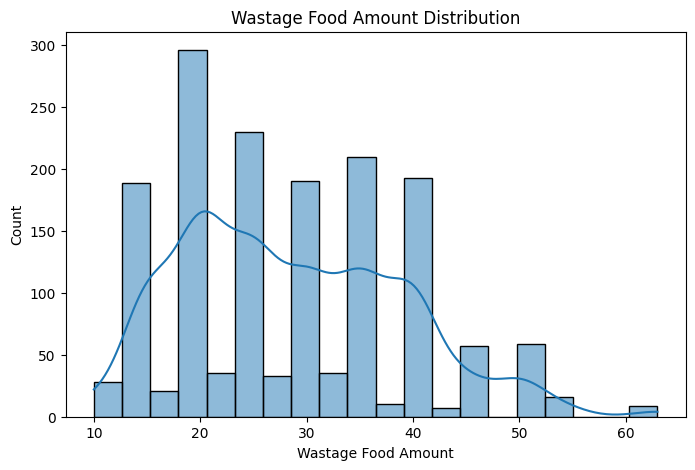

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["Wastage Food Amount"],bins=20,kde=True)
plt.title("Wastage Food Amount Distribution")
plt.xlabel("Wastage Food Amount")
plt.show()

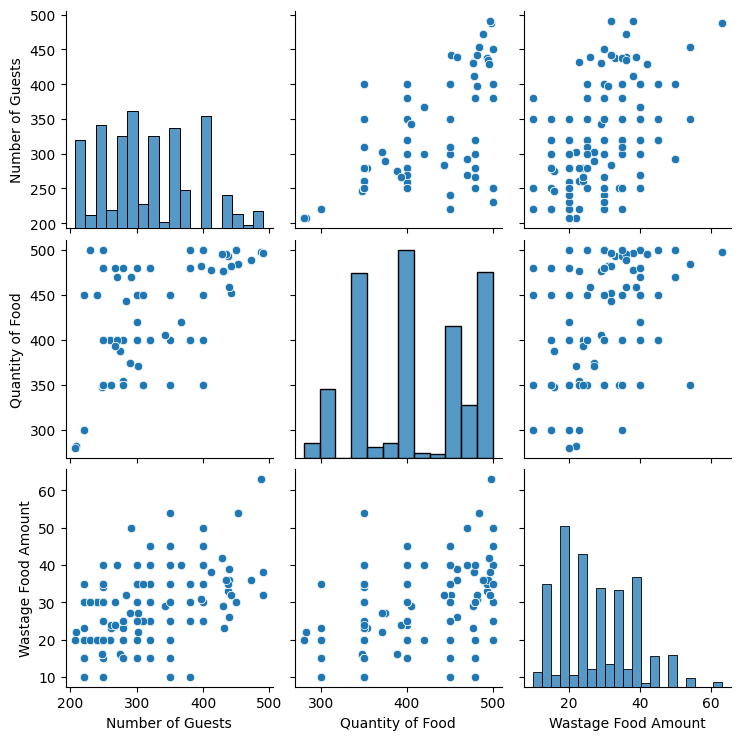

In [29]:
sns.pairplot(df[["Number of Guests","Quantity of Food","Wastage Food Amount"]])
plt.show()

In [30]:
corr = df[["Number of Guests","Quantity of Food","Wastage Food Amount"]].corr()
corr

,Number of Guests,Quantity of Food,Wastage Food Amount
Number of Guests,1.000000,0.778029,0.635116
Quantity of Food,0.778029,1.000000,0.619651
Wastage Food Amount,0.635116,0.619651,1.000000


###Creating new features

In [31]:
df["Food_Per_Guest"] = (df["Quantity of Food"] /df["Number of Guests"])
df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount,Food_Per_Guest
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25,1.451613
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40,1.250000
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27,1.228477
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32,1.012220
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25,1.333333


In [32]:
df[["Number of Guests","Quantity of Food","Food_Per_Guest","Wastage Food Amount"]].corr()

,Number of Guests,Quantity of Food,Food_Per_Guest,Wastage Food Amount
Number of Guests,1.000000,0.778029,-0.603353,0.635116
Quantity of Food,0.778029,1.000000,0.010645,0.619651
Food_Per_Guest,-0.603353,0.010645,1.000000,-0.237732
Wastage Food Amount,0.635116,0.619651,-0.237732,1.000000


In [33]:
df["Guest_Food_Interaction"] = (df["Number of Guests"] *df["Quantity of Food"])

In [34]:
df[["Number of Guests","Quantity of Food","Guest_Food_Interaction","Wastage Food Amount"]].corr()

,Number of Guests,Quantity of Food,Guest_Food_Interaction,Wastage Food Amount
Number of Guests,1.000000,0.778029,0.967622,0.635116
Quantity of Food,0.778029,1.000000,0.901381,0.619651
Guest_Food_Interaction,0.967622,0.901381,1.000000,0.660569
Wastage Food Amount,0.635116,0.619651,0.660569,1.000000


Two additional features were created to capture the relationship between food quantity and guest count.

- Food_Per_Guest = Quantity of Food / Number of Guests
- Guest_Food_Interaction = Number of Guests × Quantity of Food

The interaction feature showed a stronger relationship with food wastage than the original numerical features and was retained for model training.

###Categorical Feature Analysis.

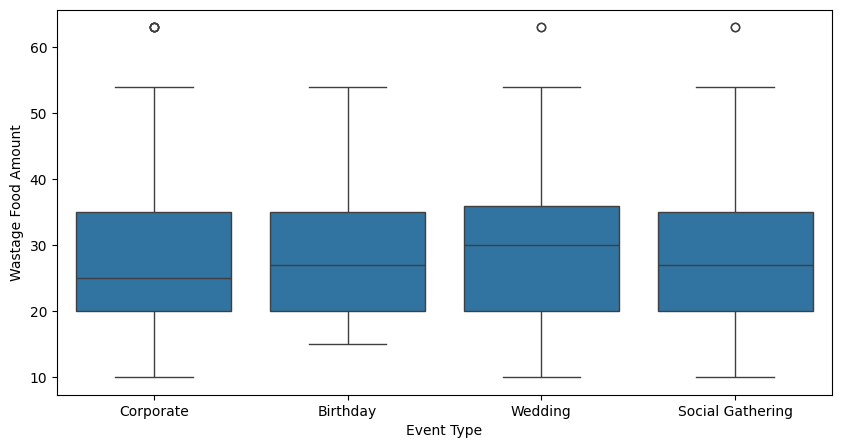

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x="Event Type",y="Wastage Food Amount",data=df)
plt.show()

Event Type Analysis

- Wedding events show the highest median food wastage.
- Corporate events have the lowest median wastage.
- Birthday and Social Gathering events show similar wastage patterns.
- The spread of food wastage is relatively similar across all event types.
- A few high-wastage outliers are present in each category.

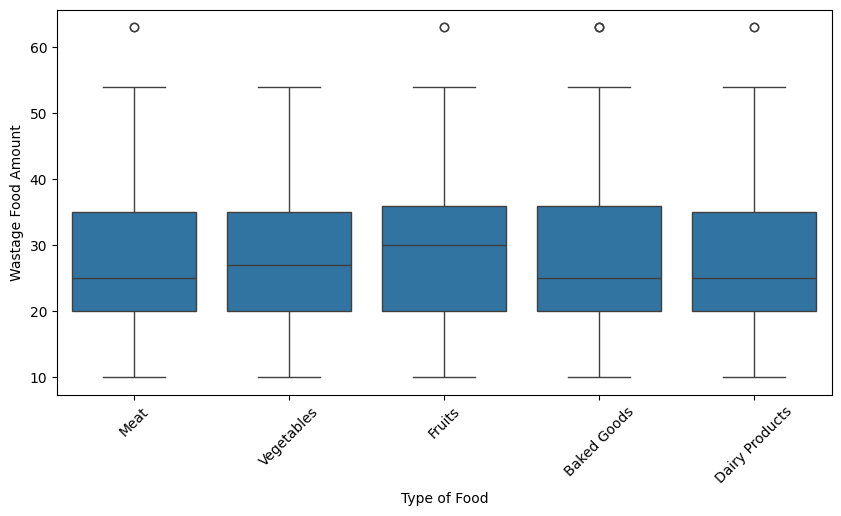

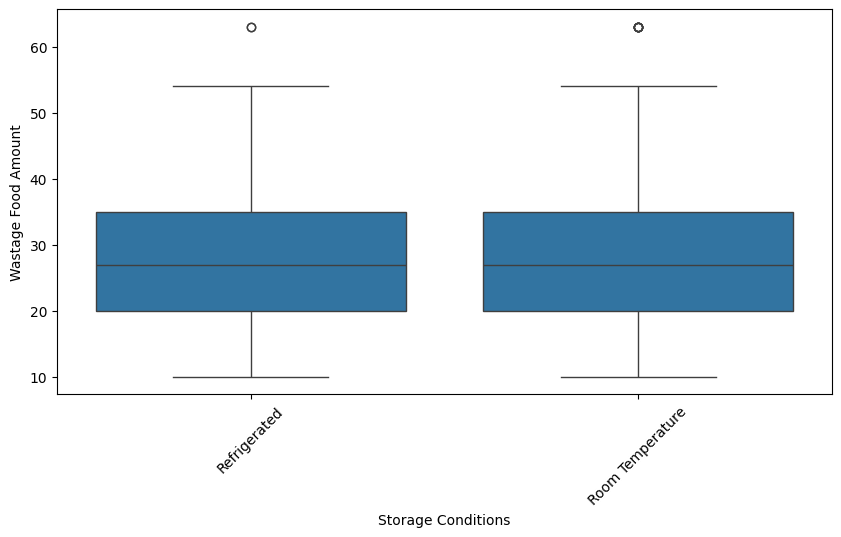

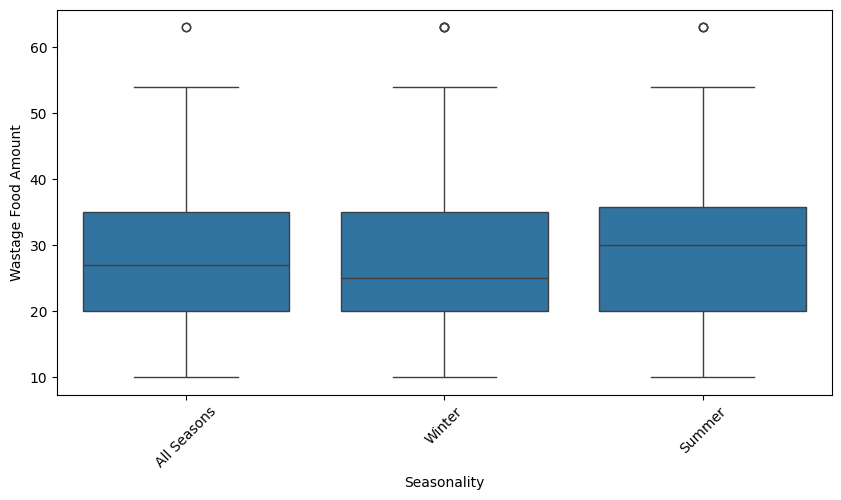

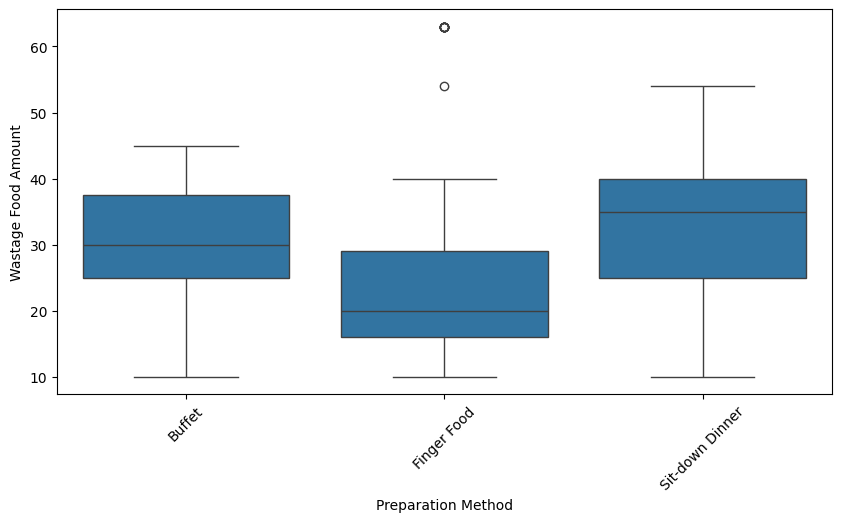

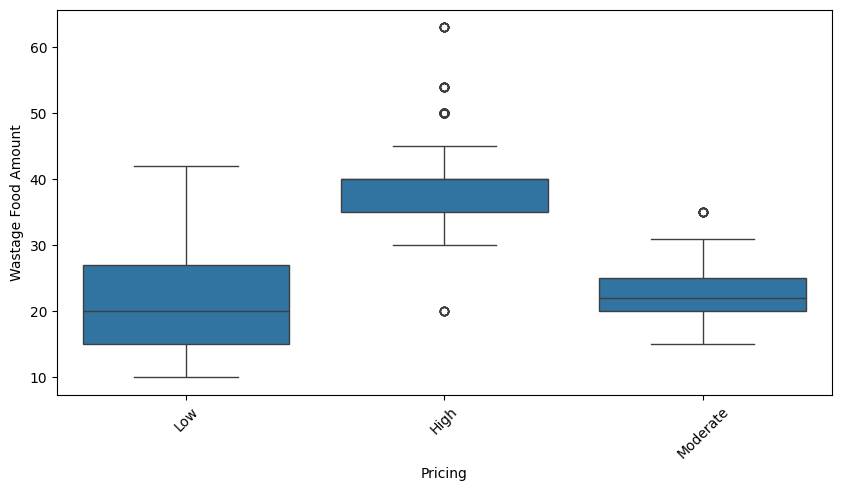

In [38]:
categorical_cols = ["Type of Food","Storage Conditions","Seasonality","Preparation Method","Pricing"]

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, y="Wastage Food Amount", data=df)
    plt.xticks(rotation=45)
    plt.show()

## Key Findings

- Number of Guests and Quantity of Food are strongly related to food wastage.
- The engineered feature Guest_Food_Interaction showed the highest correlation with the target variable.
- Summer season, sit-down dinners, weddings, and high-priced food tend to generate more wastage.
- Storage conditions showed relatively little influence on wastage.
- No missing values were present in the dataset.
- Duplicate records were removed before model development.

###Final data preparation and Model preparation

In [39]:
X = df.drop("Wastage Food Amount", axis=1)
y = df["Wastage Food Amount"]

In [40]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

categorical_cols = df_model.select_dtypes(include="object").columns

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

In [41]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Wastage Food Amount", axis=1)
y = df_model["Wastage Food Amount"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200,random_state=42)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [43]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

preds = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds)**0.5)
print("R2  :", r2_score(y_test, preds))

MAE : 1.7217050631981186
RMSE: 2.870118601313279
R2  : 0.9235490734103089


- The model explains approximately 92.4% of the variance in food wastage.
- Average prediction error is around 1.7 units of food wastage.
- The model demonstrates strong predictive performance on unseen data.
- Feature engineering contributed positively to model performance.

In [44]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

from sklearn.metrics import r2_score

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))

Train R2: 0.9830315014699569
Test R2 : 0.9235490734103089


In [45]:
import pandas as pd

importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance)

                   Feature  Importance
9                  Pricing    0.600857
1         Number of Guests    0.117197
10          Food_Per_Guest    0.069000
11  Guest_Food_Interaction    0.059768
3         Quantity of Food    0.053142
7       Preparation Method    0.045426
0             Type of Food    0.013460
8    Geographical Location    0.012800
2               Event Type    0.011703
6              Seasonality    0.009231
4       Storage Conditions    0.004267
5         Purchase History    0.003150


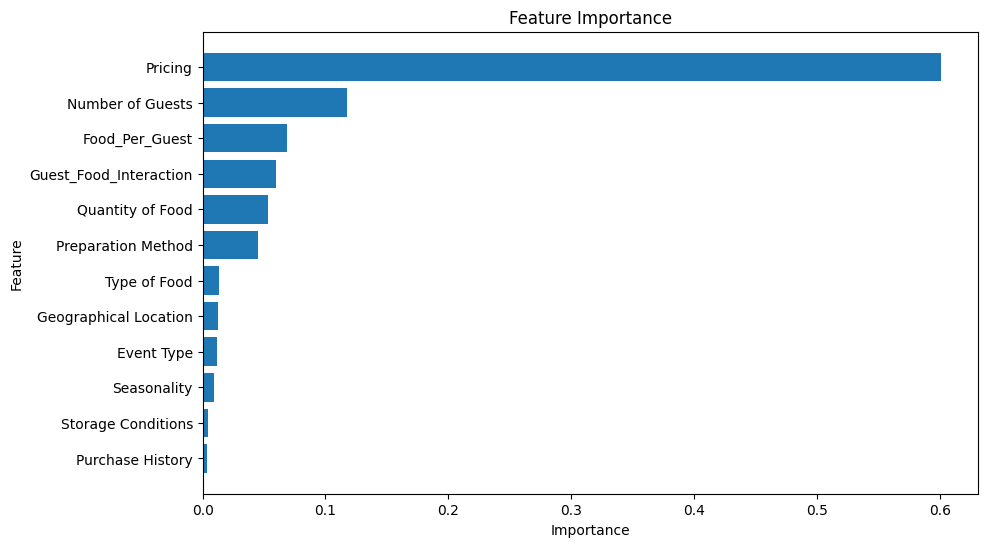

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(importance["Feature"],importance["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()

plt.show()

## Feature Importance Analysis

Pricing emerged as the most influential factor in predicting food wastage, contributing approximately 60% of the total feature importance.

Other important predictors included:

- Number of Guests
- Food_Per_Guest
- Guest_Food_Interaction
- Quantity of Food

Storage Conditions and Purchase History showed minimal influence on food wastage prediction.

In [47]:
!pip install xgboost -q

In [49]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb = XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=4,subsample=0.8,colsample_bytree=0.8,objective="reg:squarederror",random_state=42)

xgb.fit(X_train, y_train,eval_set=[(X_test,y_test)],
        verbose=False)

xgb_pred = xgb.predict(X_test)



In [50]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

preds = xgb.predict(X_test)

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds)**0.5)
print("R2  :", r2_score(y_test, preds))

MAE : 1.938803791999817
RMSE: 2.7487025234533773
R2  : 0.9298805594444275


In [51]:
train_preds = xgb.predict(X_train)

print("Train R2:", r2_score(y_train, train_preds))
print("Test R2 :", r2_score(y_test, preds))

Train R2: 0.9555233120918274
Test R2 : 0.9298805594444275


In [52]:
import pandas as pd

importance = pd.DataFrame({"Feature": X.columns,"Importance": xgb.feature_importances_})

importance.sort_values(by="Importance",ascending=False,inplace=True)

print(importance)

                   Feature  Importance
9                  Pricing    0.568264
11  Guest_Food_Interaction    0.132527
3         Quantity of Food    0.080843
1         Number of Guests    0.068782
10          Food_Per_Guest    0.060638
7       Preparation Method    0.049510
8    Geographical Location    0.010449
4       Storage Conditions    0.006491
0             Type of Food    0.006160
5         Purchase History    0.005543
6              Seasonality    0.005429
2               Event Type    0.005365


In [53]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {"n_estimators": [200, 400, 600, 800, 1000],"max_depth": [3, 4, 5, 6, 7],"learning_rate": [0.01, 0.03, 0.05, 0.1],"subsample": [0.7, 0.8, 0.9, 1.0],"colsample_bytree": [0.7, 0.8, 0.9, 1.0]}

xgb_model = XGBRegressor(objective="reg:squarederror",random_state=42)

random_search = RandomizedSearchCV( estimator=xgb_model,param_distributions=param_grid,n_iter=25,cv=5,scoring="r2",verbose=1,n_jobs=-1,random_state=42)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [54]:
print(random_search.best_params_)

{'subsample': 1.0, 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [55]:
best_xgb = random_search.best_estimator_

preds = best_xgb.predict(X_test)

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds)**0.5)
print("R2  :", r2_score(y_test, preds))

MAE : 1.8761239051818848
RMSE: 2.742849764501775
R2  : 0.9301788210868835


In [56]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00


In [57]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(iterations=1000,learning_rate=0.05,depth=6,loss_function="RMSE",random_state=42,verbose=0)

cat.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)

In [58]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

preds = cat.predict(X_test)

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds)**0.5)
print("R2  :", r2_score(y_test, preds))

MAE : 1.954074775728353
RMSE: 2.7646615793214524
R2  : 0.9290639468232074


In [59]:
import pandas as pd

importance = pd.DataFrame({"Feature": X.columns,"Importance": cat.feature_importances_})

importance.sort_values(by="Importance",ascending=False,inplace=True)

print(importance)

                   Feature  Importance
9                  Pricing   47.762168
10          Food_Per_Guest   10.275957
3         Quantity of Food    9.670535
11  Guest_Food_Interaction    8.911717
7       Preparation Method    8.604993
1         Number of Guests    7.064657
8    Geographical Location    2.480626
2               Event Type    1.605984
0             Type of Food    1.457985
6              Seasonality    1.108282
4       Storage Conditions    0.606196
5         Purchase History    0.450901


In [60]:
from sklearn.ensemble import VotingRegressor

voting = VotingRegressor(estimators=[("rf", rf),("xgb", best_xgb),("cat", cat)])

voting.fit(X_train, y_train)

preds = voting.predict(X_test)

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds)**0.5)
print("R2  :", r2_score(y_test, preds))

MAE : 1.810787943937979
RMSE: 2.7201007560036965
R2  : 0.931332213364568


## Ensemble Learning Results

A Voting Regressor combining Random Forest, XGBoost, and CatBoost achieved the best overall performance.

The ensemble reduced prediction error and improved generalization by leveraging the strengths of multiple models.

This approach outperformed all individual models tested during experimentation.

In [61]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

stack = StackingRegressor(estimators=[("rf", rf),("xgb", best_xgb),("cat", cat)],final_estimator=Ridge())

stack.fit(X_train, y_train)

preds = stack.predict(X_test)

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", mean_squared_error(y_test, preds)**0.5)
print("R2  :", r2_score(y_test, preds))

MAE : 1.8498329135244898
RMSE: 2.7474919121526393
R2  : 0.9299422940727308


## Model Comparison

Multiple machine learning models were trained and evaluated for surplus food prediction.

Models evaluated:

- Random Forest Regressor
- XGBoost Regressor
- Tuned XGBoost Regressor
- CatBoost Regressor
- Voting Regressor
- Stacking Regressor

The Voting Ensemble achieved the highest predictive performance with an R² score of 0.9313 and the lowest overall prediction error.

## Final Model Selection

The Voting Regressor was selected as the final production model because it achieved the best balance of accuracy and generalization.

Final Metrics:

- MAE: 1.811
- RMSE: 2.720
- R² Score: 0.9313

The model combines Random Forest, XGBoost, and CatBoost predictions, leveraging the strengths of multiple learning algorithms to improve prediction robustness.

###Save Final Model

In [62]:
import joblib

joblib.dump(voting, "shareplate_surplus_food_predictor.pkl")

['shareplate_surplus_food_predictor.pkl']